# Coffee Bean Dataset: Exploratory Data Analysis (EDA)

This notebook explores the Coffee Bean Dataset (224x224) to understand:
- Class distribution
- Visual differences between roast levels
- Pixel-level patterns (color, brightness)
- Feasibility of classification

Goal: Assess whether visual features can be used to predict roast level and, indirectly, taste profiles.

# 1. Package + Data import

- In this step, we import all necessary libraries for data loading, image processing, and visualization.
- We use kagglehub to programmatically download the Coffee Bean Dataset, which contains 224×224 RGB images organized into class folders.
- The dataset is structured for supervised classification, with each folder representing a roast level.

In [19]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter

In [20]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("gpiosenka/coffee-bean-dataset-resized-224-x-224")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\raozg\.cache\kagglehub\datasets\gpiosenka\coffee-bean-dataset-resized-224-x-224\versions\1


In [50]:
data_dir = r"C:\Users\raozg\.cache\kagglehub\datasets\gpiosenka\coffee-bean-dataset-resized-224-x-224\versions\1"
data_dir = os.path.join(path, "train")
classes = os.listdir(data_dir)

# 2. Class Distribution

In [52]:
class_counts = {}

for cls in classes:
    class_counts[cls] = len(os.listdir(os.path.join(data_dir, cls)))

class_counts

{'Dark': 300, 'Green': 300, 'Light': 300, 'Medium': 300}

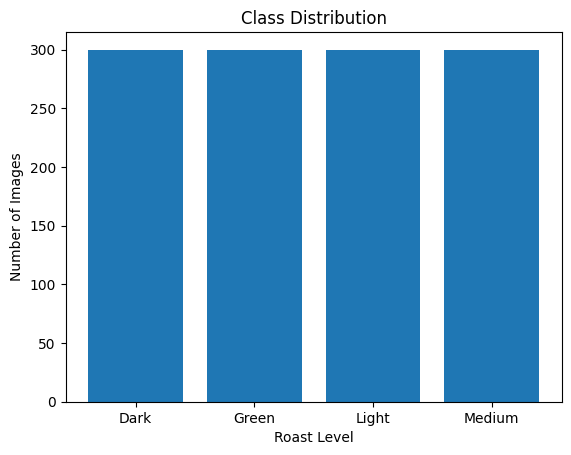

In [53]:
plt.bar(class_counts.keys(), class_counts.values())
plt.title("Class Distribution")
plt.xlabel("Roast Level")
plt.ylabel("Number of Images")
plt.show()

- **What we did**: We counted the number of images per roast level (Dark, Green, Light, Medium) and visualized the distribution as a bar chart.
- **Result**: Each class contains exactly 300 images, giving us a perfectly balanced dataset of 1,200 training images total.
- **Interpretation**: A balanced dataset is ideal: it means the model won't be biased toward predicting any particular roast level due to overrepresentation. We can use standard accuracy as a reliable metric without needing to apply class weighting or resampling techniques.

# 3. Visual Inspection

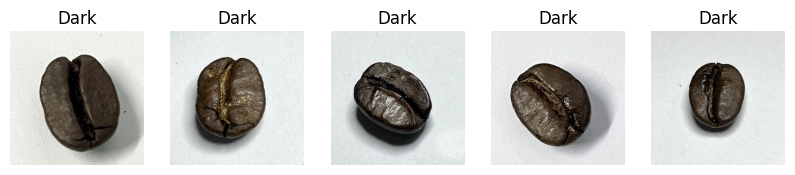

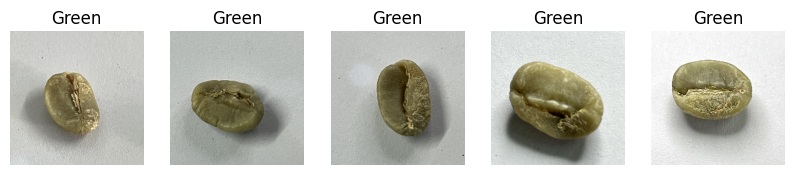

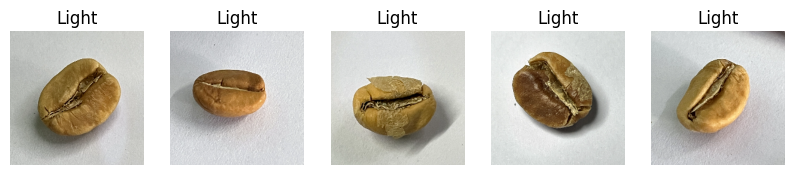

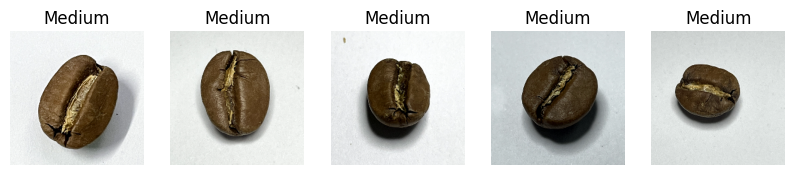

In [54]:
def show_samples(data_dir, n=5):
    for cls in classes:
        images = os.listdir(os.path.join(data_dir, cls))
        sample = random.sample(images, n)

        plt.figure(figsize=(10,2))
        for i, img_name in enumerate(sample):
            img = Image.open(os.path.join(data_dir, cls, img_name))
            plt.subplot(1, n, i+1)
            plt.imshow(img)
            plt.title(cls)
            plt.axis("off")
        plt.show()

show_samples(data_dir)

- **What we did**: We randomly sampled 5 images from each class and displayed them side by side to get an intuitive sense of what differentiates the roast levels visually.
- **Result**: Even at a glance, the roast levels show clear visual differences. light roast beans appear pale and matte, medium roast beans are a warm brown, dark roast beans look visibly darker and sometimes oily, and green (unroasted) beans have a distinct yellow-green tone.
- **Interpretation**: These differences are perceptible to the human eye, which strongly suggests that a model trained on pixel-level features/ especially color /should be able to distinguish between classes. This is a positive signal for classification feasibility.

# 4. Image Properties Check

In [55]:
shapes = set()

for cls in classes:
    for img_name in os.listdir(os.path.join(data_dir, cls))[:50]:
        img = Image.open(os.path.join(data_dir, cls, img_name))
        shapes.add(np.array(img).shape)

shapes

{(224, 224, 3)}

- **What we did**: We iterated over the first 50 images in each class and collected their array shapes to verify consistency across the dataset.
- **Result**: All images are uniformly shaped at (224, 224, 3), meaning 224×224 pixels with 3 RGB color channels. No inconsistencies were found.
- **Interpretation**: Consistent image dimensions are a basic but important requirement for feeding data into a Convolutional Neural Network (CNN). Since all images are already the same size, we won't need to apply any resizing or padding during preprocessing, which simplifies our pipeline.

# 5. Average Color per Class

In [56]:
def avg_color_per_class(data_dir):
    avg_colors = {}

    for cls in classes:
        pixels = []
        for img_name in os.listdir(os.path.join(data_dir, cls))[:200]:
            img = np.array(Image.open(os.path.join(data_dir, cls, img_name)))
            pixels.append(img.mean(axis=(0,1)))

        avg_colors[cls] = np.mean(pixels, axis=0)

    return avg_colors

avg_colors = avg_color_per_class(data_dir)
avg_colors

{'Dark': array([182.27103974, 182.91715123, 180.42323292]),
 'Green': array([182.07162279, 181.66171357, 173.28283622]),
 'Light': array([186.44447495, 180.85841677, 166.61196259]),
 'Medium': array([182.85214037, 180.5565057 , 173.7059104 ])}

- **What we did**: For each class, we computed the average RGB pixel value across 200 images and summarized them as three-channel color vectors (R, G, B).
- **Result**:
ClassRGBDark182.3182.9180.4Green182.1181.7173.3Light186.4180.9166.6Medium182.9180.6173.7
- **Interpretation**: The differences are subtle but meaningful. Light roast beans have a notably lower blue channel value, giving them a warmer tone. Dark roast beans show more balanced RGB values, consistent with their neutral-dark appearance. Green beans sit between the two in terms of blue channel. This confirms that color alone carries discriminative information across roast levels — a CNN operating on raw pixels should naturally pick this up through its early convolutional filters.

# 6. Brightness Distribution

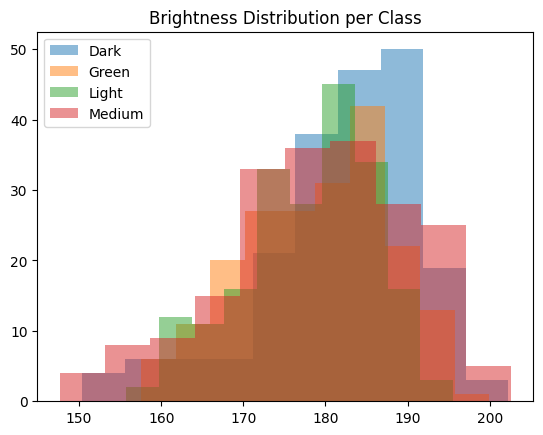

In [57]:
def compute_brightness(img):
    return np.mean(img)

brightness = {cls: [] for cls in classes}

for cls in classes:
    for img_name in os.listdir(os.path.join(data_dir, cls))[:200]:
        img = np.array(Image.open(os.path.join(data_dir, cls, img_name)))
        brightness[cls].append(compute_brightness(img))

for cls, values in brightness.items():
    plt.hist(values, alpha=0.5, label=cls)

plt.legend()
plt.title("Brightness Distribution per Class")
plt.show()

- **What we did**: We computed the mean pixel intensity (brightness) for each image across all classes and plotted the distributions as overlapping histograms.
- **Result**: The brightness distributions show meaningful separation between classes. Light roast images tend to have higher brightness values, while Dark roast images cluster at lower values. Green and Medium roast distributions overlap somewhat in the middle range.
- **Interpretation**: Brightness is a strong single-feature signal for distinguishing roast level. However, the overlap between Green and Medium suggests that brightness alone isn't sufficient for full four-class separation. A CNN will need to learn additional texture and color-pattern features to reliably distinguish these intermediate classes.

# 7. Duplicate Check

In [58]:
import hashlib

def file_hash(path):
    with open(path, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

hashes = set()
duplicates = 0

for cls in classes:
    for img_name in os.listdir(os.path.join(data_dir, cls)):
        path = os.path.join(data_dir, cls, img_name)
        h = file_hash(path)
        if h in hashes:
            duplicates += 1
        hashes.add(h)

print("Duplicates found:", duplicates)

Duplicates found: 6


- **What we did**: We computed an MD5 hash for every image in the training set and flagged any files that shared an identical hash.
- **Result**: 6 duplicate images were detected across the dataset.
- **Interpretation**: 6 duplicates out of 1,200 images is a very small proportion and unlikely to meaningfully affect model performance. That said, it's good practice to be aware of this, duplicates that appear in both training and validation splits could lead to slight overestimation of model accuracy. If we apply a strict train/val split, we should consider deduplicating beforehand.

# 8. Color

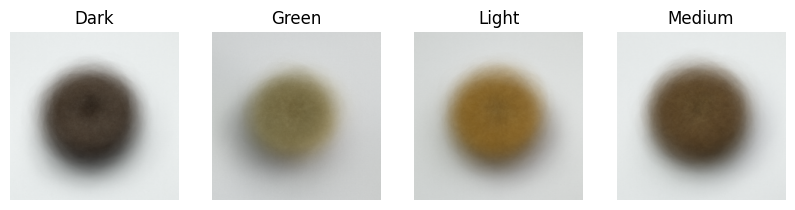

In [86]:
def mean_image(data_dir, cls):
    imgs = []
    for img_name in os.listdir(os.path.join(data_dir, cls))[:200]:
        img = np.array(Image.open(os.path.join(data_dir, cls, img_name)))
        imgs.append(img)
    return np.mean(imgs, axis=0).astype(np.uint8)

plt.figure(figsize=(10,3))

for i, cls in enumerate(classes):
    plt.subplot(1, len(classes), i+1)
    plt.imshow(mean_image(data_dir, cls))
    plt.title(cls)
    plt.axis("off")

plt.show()

- **What we did**: We averaged the pixel values of 200 images per class to construct a single "mean image" that represents the typical visual appearance of each roast level.
- **Result**: The mean images reveal clear color differences between classes. The Light roast mean image appears noticeably warmer and paler, while the Dark roast mean image is more neutral and muted. The Green roast has a distinct yellowish-green tint, and Medium sits visually between Light and Dark.
- **Interpretation**: Mean images are a powerful sanity check, if the classes weren't visually distinct, the averaged images would all look similar. The fact that they differ confirms that the visual signal in this dataset is consistent and not just noise. This bodes well for a CNN being able to generalize from training examples to unseen images.

# Conclusion

The EDA gives us strong confidence in the viability of this project. Key takeaways:

- Balanced classes ensure fair model training without resampling
- Color and brightness are strong predictors of roast level
- All images are consistently sized at 224×224×3, ready for CNN input
- Visual inspection confirms that roast levels are perceptually distinguishable
- Minimal data quality issues (only 6 duplicates found)

 -- The next logical step is to build and train a CNN classifier on this dataset, then map predicted roast levels to taste profiles to make the model practically useful. --

# Extra: Principle Component Analysis

1. Prepare the data

- X → flattened images
- y → labels (Dark/Light)

In [67]:
import numpy as np
from sklearn.decomposition import PCA

X = []
y = []

for cls in classes:
    for img_name in os.listdir(os.path.join(data_dir, cls))[:100]:  # limit for speed
        img = np.array(Image.open(os.path.join(data_dir, cls, img_name)))
        X.append(img.flatten())   # convert 224x224x3 → 1D vector
        y.append(cls)

X = np.array(X)
y = np.array(y)

print("Shape of X:", X.shape)

Shape of X: (400, 150528)


2. Standardize

In [68]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

3. Apply PCA

In [69]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance:", pca.explained_variance_ratio_)

Explained variance: [0.31303673 0.09112986]


4. Plot

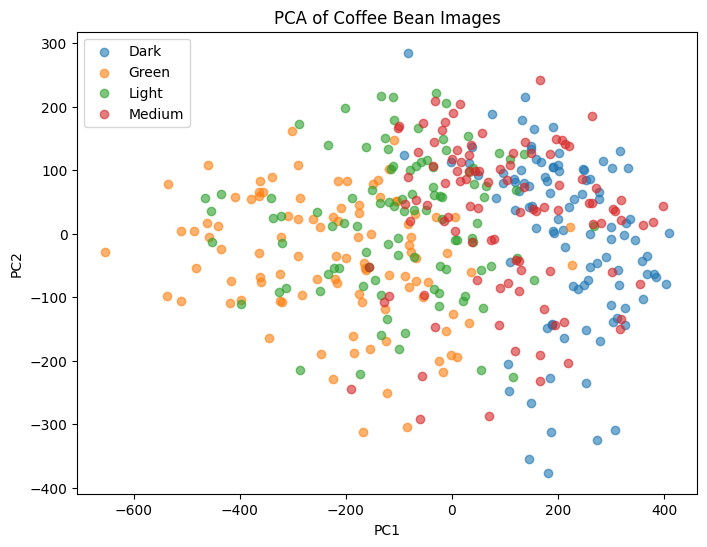

In [72]:
plt.figure(figsize=(8,6))

for cls in classes:
    idx = (y == cls)
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=cls, alpha=0.6)

plt.legend()
plt.title("PCA of Coffee Bean Images")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

- **Interpretation**: PC1 appears to primarily capture the difference between unroasted (Green) and roasted beans, which makes intuitive sense, since green beans look fundamentally different in color and texture from any roasted variety. However, PC1 and PC2 together are not sufficient to separate the three roast levels (Light, Medium, Dark) from one another, their clusters overlap almost entirely in this 2D projection.
This tells us two things:

1. The most visually obvious distinction in the dataset is roasted vs. unroasted, not the gradient between roast levels.
Distinguishing Light, Medium, and Dark from each other likely requires higher-order, nonlinear features that PCA (being a linear method) simply cannot capture in 2 dimensions.

2. This is exactly where a CNN has a major advantage: it learns hierarchical texture and color features that go well beyond what raw pixel PCA can reveal.

In [74]:
import pandas as pd

df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Class": y
})

In [85]:
import plotly.express as px

fig = px.scatter(
    df,
    x="PC1",
    y="PC2",
    color="Class",
    title="PCA of Coffee Bean Images",
    width=800,
    height=600
)

fig.show()

In [84]:
import plotly.express as px
import pandas as pd

df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Class": y
})

fig = px.scatter(
    df,
    x="PC1",
    y="PC2",
    color="Class",
    color_discrete_sequence=px.colors.qualitative.Dark24,
    title="PCA of Coffee Bean Images"
)

fig.update_traces(marker=dict(size=6, opacity=0.6))

fig.update_layout(
    xaxis_title="Principal Component 1",
    yaxis_title="Principal Component 2",
    legend_title="Roast Level"
)

fig.show()

- **What we did**: We applied Principal Component Analysis (PCA) to a subset of 100 images per class (400 total). Each image was flattened from a 224×224×3 array into a 150,528-dimensional vector, standardized, and then projected down to 2 principal components for visualization.
- **Result**: The scatter plot shows that classes begin to form distinct clusters, while Green and Medium show more overlap.